# EDA

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import math
from scipy.stats import skew, kurtosis

In [39]:
# PATHS
PROJECT_PATH = Path("../").resolve()
DATA_PATH = PROJECT_PATH / "data"
DATA_FEATURES_PATH = DATA_PATH / "NUSW-NB15_features.csv"
DATA_TESTING_PATH = DATA_PATH / "UNSW_NB15_testing-set.csv"
DATA_TRAINING_SET_PATH = DATA_PATH / "UNSW_NB15_training-set.csv"
DATA_1_PATH = DATA_PATH / "UNSW-NB15_1.csv"
DATA_2_PATH = DATA_PATH / "UNSW-NB15_2.csv"
DATA_3_PATH = DATA_PATH / "UNSW-NB15_3.csv"
DATA_4_PATH = DATA_PATH / "UNSW-NB15_4.csv"
DATA_LIST_EVENTS_PATH = DATA_PATH / "UNSW-NB15_LIST_EVENTS.csv"

## Chargement des dataset

In [40]:
df_data_features = pd.read_csv(DATA_FEATURES_PATH, encoding="cp1252")
df_data_features.head(len(df_data_features))

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


Le dataset "NUSW-NB15_features.csv" contient les noms, types et descriptions des features.

In [41]:
df_data_training_set = pd.read_csv(DATA_TRAINING_SET_PATH)
df_data_training_set.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


Le dataset "NUSW-NB15_training-set.csv" est le jeu d'entraînement sur lequel nous entraîneront les algorithmes de clusterisation.

In [42]:
print(
    f"Dimension du dataset training-set : {df_data_training_set.shape[0]} lignes et {df_data_training_set.shape[1]} colonnes"
)

Dimension du dataset training-set : 82332 lignes et 45 colonnes


In [43]:
def compare_columns(df1, df2, name1="df1", name2="df2"):
    cols1 = set([c.lower() for c in df1.columns])
    cols2 = set([c.lower() for c in df2.columns])

    only_in_df1 = cols1 - cols2
    only_in_df2 = cols2 - cols1
    common = cols1 & cols2

    print(f"\nColonnes uniquement dans {name1} ({len(only_in_df1)}):")
    print(sorted(only_in_df1))

    print(f"\nColonnes uniquement dans {name2} ({len(only_in_df2)}):")
    print(sorted(only_in_df2))

    print(f"\nColonnes communes ({len(common)}):")
    print(sorted(common))

    return {"only_in_df1": only_in_df1, "only_in_df2": only_in_df2, "common": common}


_ = compare_columns(
    df_data_features.set_index("Name").T,
    df_data_training_set,
    name1="df_data_features",
    name2="df_data_training_set",
)


Colonnes uniquement dans df_data_features (12):
['ct_src_ ltm', 'dintpkt', 'dmeansz', 'dsport', 'dstip', 'ltime', 'res_bdy_len', 'sintpkt', 'smeansz', 'sport', 'srcip', 'stime']

Colonnes uniquement dans df_data_training_set (8):
['ct_src_ltm', 'dinpkt', 'dmean', 'id', 'rate', 'response_body_len', 'sinpkt', 'smean']

Colonnes communes (37):
['ackdat', 'attack_cat', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_ftp_cmd', 'ct_src_dport_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_state_ttl', 'dbytes', 'djit', 'dload', 'dloss', 'dpkts', 'dtcpb', 'dttl', 'dur', 'dwin', 'is_ftp_login', 'is_sm_ips_ports', 'label', 'proto', 'sbytes', 'service', 'sjit', 'sload', 'sloss', 'spkts', 'state', 'stcpb', 'sttl', 'swin', 'synack', 'tcprtt', 'trans_depth']


* Colonnes aux nom similaires :

| df_data_features |df_data_training_set |
| :- | :- |
| 'ct_src_ ltm' | 'ct_src_ltm' |
| 'dintpkt' | 'dinpkt' |
| 'dmeansz' | 'dmean' |
| 'res_bdy_len' | 'response_body_len' |
| 'sintpkt' | 'sinpkt' |
| 'smeansz' | 'smean' |

* Features non présentes dans le dataset training_set : 'dsport', 'dstip', 'ltime', 'sport', 'srcip', 'stime'.
* Colonnes non présentes dans les features : 'rate' et 'id'.

In [44]:
df_data_list_events = pd.read_csv(DATA_LIST_EVENTS_PATH)
df_data_list_events.head()

,Attack category,Attack subcategory,Number of events
0,normal,NaN,2218761
1,Fuzzers,FTP,558
2,Fuzzers,HTTP,1497
3,Fuzzers,RIP,3550
4,Fuzzers,SMB,5245


Le dataset "NUSW-NB15_LIST_EVENTS.csv" présente la répartition des attaques.

## Analyse des features

In [45]:
df_features = df_data_training_set.drop(["id", "label"], axis=1)

In [77]:
num_features = df_features.select_dtypes(include=np.number).columns.to_list()
num_features_float = df_features.select_dtypes(include=float).columns.to_list()
num_features_int = df_features.select_dtypes(include=int).columns.to_list()
cat_features = df_features.select_dtypes(include=["object", str]).columns.to_list()

print("Features numériques : ", num_features)
print("Features catégorielles : ", cat_features)

Features numériques :  ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']
Features catégorielles :  ['proto', 'service', 'state', 'attack_cat']


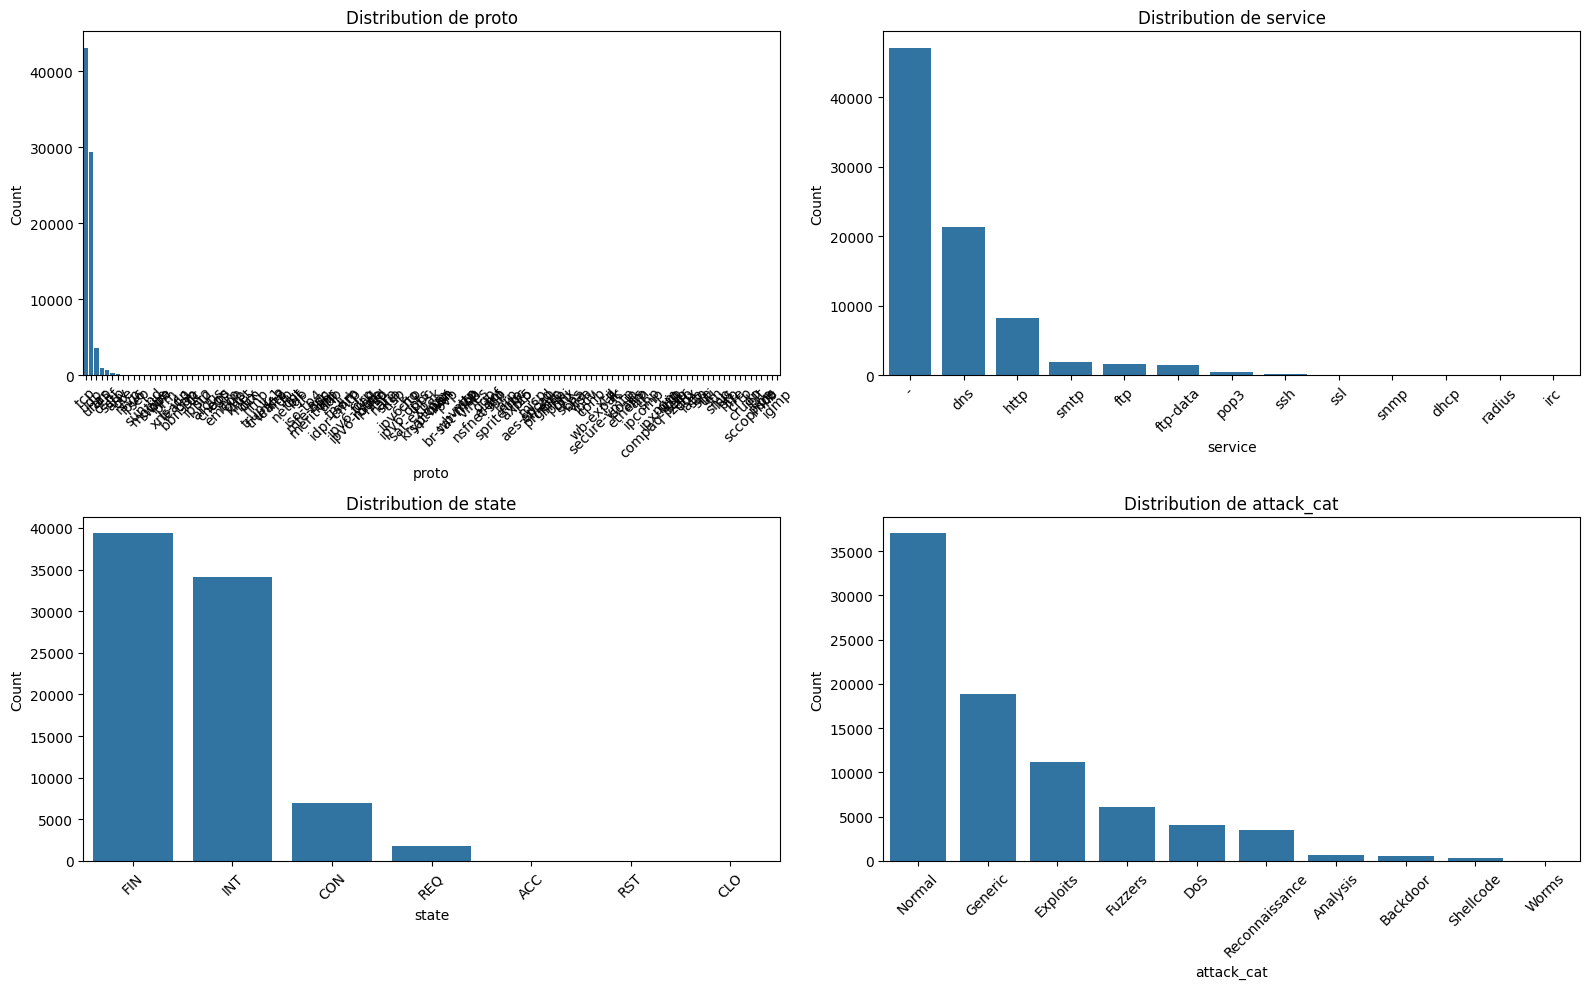

In [78]:
plt.figure(figsize=(16, 10))

for i, col in enumerate(cat_features, 1):
    plt.subplot(2, 2, i)
    counts = df_features[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [79]:
def analyze_missing_date(df: pd.DataFrame) -> pd.DataFrame:
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)
    df_missing = pd.DataFrame(
        {
            "Colonnes": missing.index,
            "Valeurs manquantes": missing.values,
            "Pourcentages": missing_pct.values,
        }
    )
    df_missing = df_missing[df_missing["Valeurs manquantes"] > 0].sort_values(
        "Pourcentages", ascending=False
    )
    return df_missing


missing_data = analyze_missing_date(df_features)
if len(missing_data) > 0:
    print(missing_data.head(len(missing_data)))
else:
    print("Pas de données manquantes")

Pas de données manquantes


In [80]:
def detecter_outliers(serie):
    Q1, Q3 = serie.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR
    outliers = ((serie < borne_basse) | (serie > borne_haute)).sum()
    return outliers, borne_basse, borne_haute


outliers = {
    "variable": [],
    "outliers": [],
    "outliers_percentages": [],
    "borne_inf": [],
    "borne_sup": [],
}

for var in num_features:
    n_out, bb, bh = detecter_outliers(df_features[var])
    pct = n_out / len(df_features) * 100
    outliers["variable"].append(var)
    outliers["outliers"].append(n_out)
    outliers["outliers_percentages"].append(pct)
    outliers["borne_inf"].append(bb)
    outliers["borne_sup"].append(bh)

df_outliers = pd.DataFrame(outliers)
df_outliers.sort_values("outliers_percentages", ascending=False).head(10)

,variable,outliers,outliers_percentages,borne_inf,borne_sup
9,dload,18112,21.998737,-23787.123413,39645.205687
32,ct_dst_src_ltm,12789,15.533450,-6.500000,13.500000
4,dbytes,12308,14.949230,-1434.000000,2390.000000
23,smean,11928,14.487684,-7.500000,164.500000
30,ct_src_dport_ltm,11476,13.938687,-3.500000,8.500000
11,dloss,11272,13.690910,-3.000000,5.000000
31,ct_dst_sport_ltm,10907,13.247583,-2.000000,6.000000
29,ct_dst_ltm,10479,12.727736,-6.500000,13.500000
1,spkts,10196,12.384006,-13.000000,27.000000
27,ct_srv_src,10093,12.258903,-11.500000,24.500000


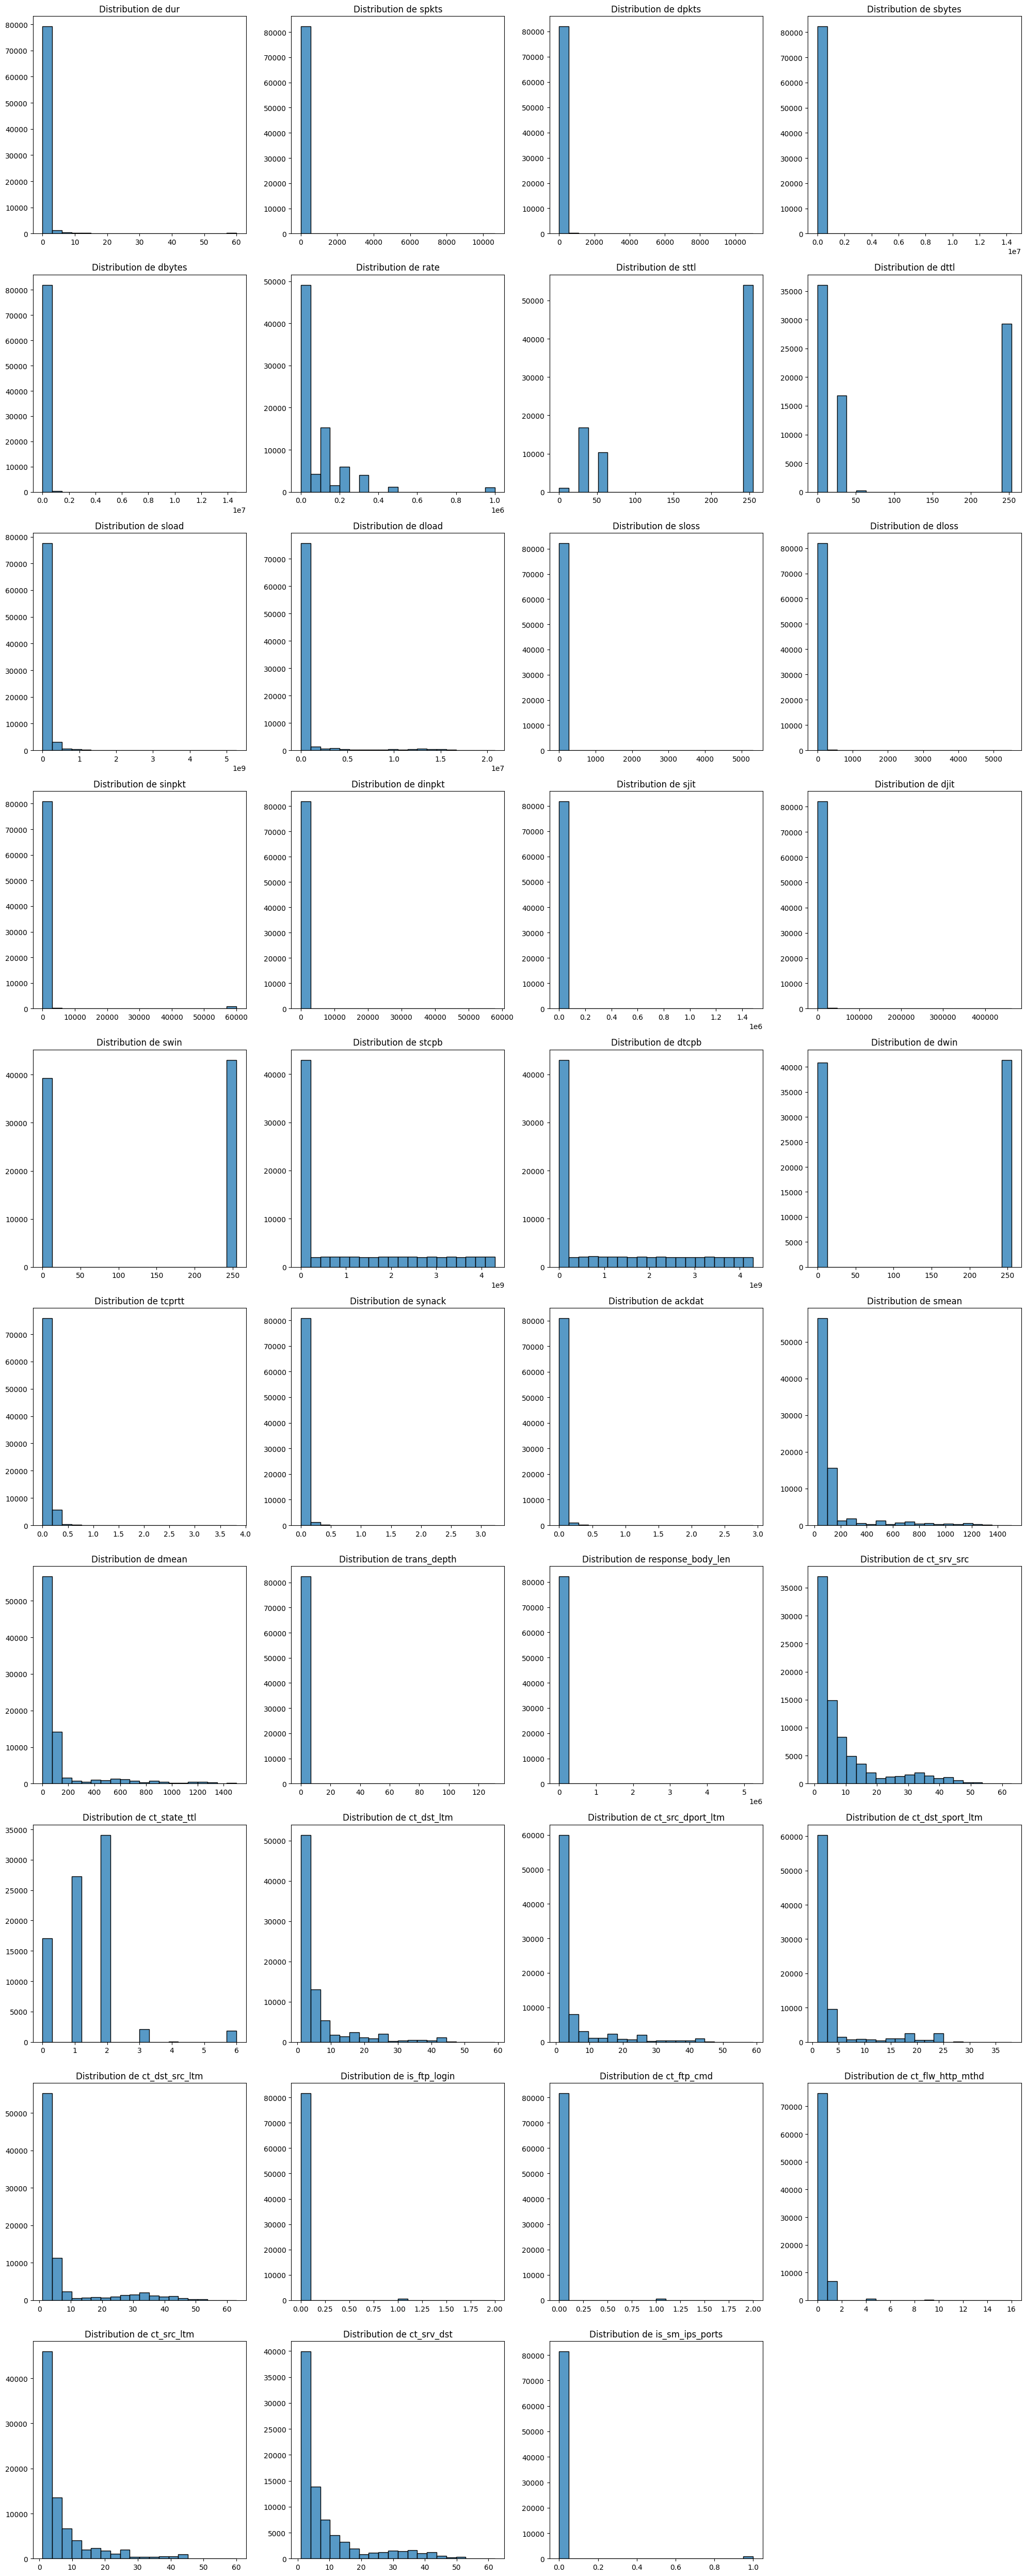

In [87]:
n_cols = 4
n_rows = math.ceil(len(num_features) / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(num_features, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.histplot(df_features[col], bins=20)

    plt.title(f"Distribution de {col}")
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

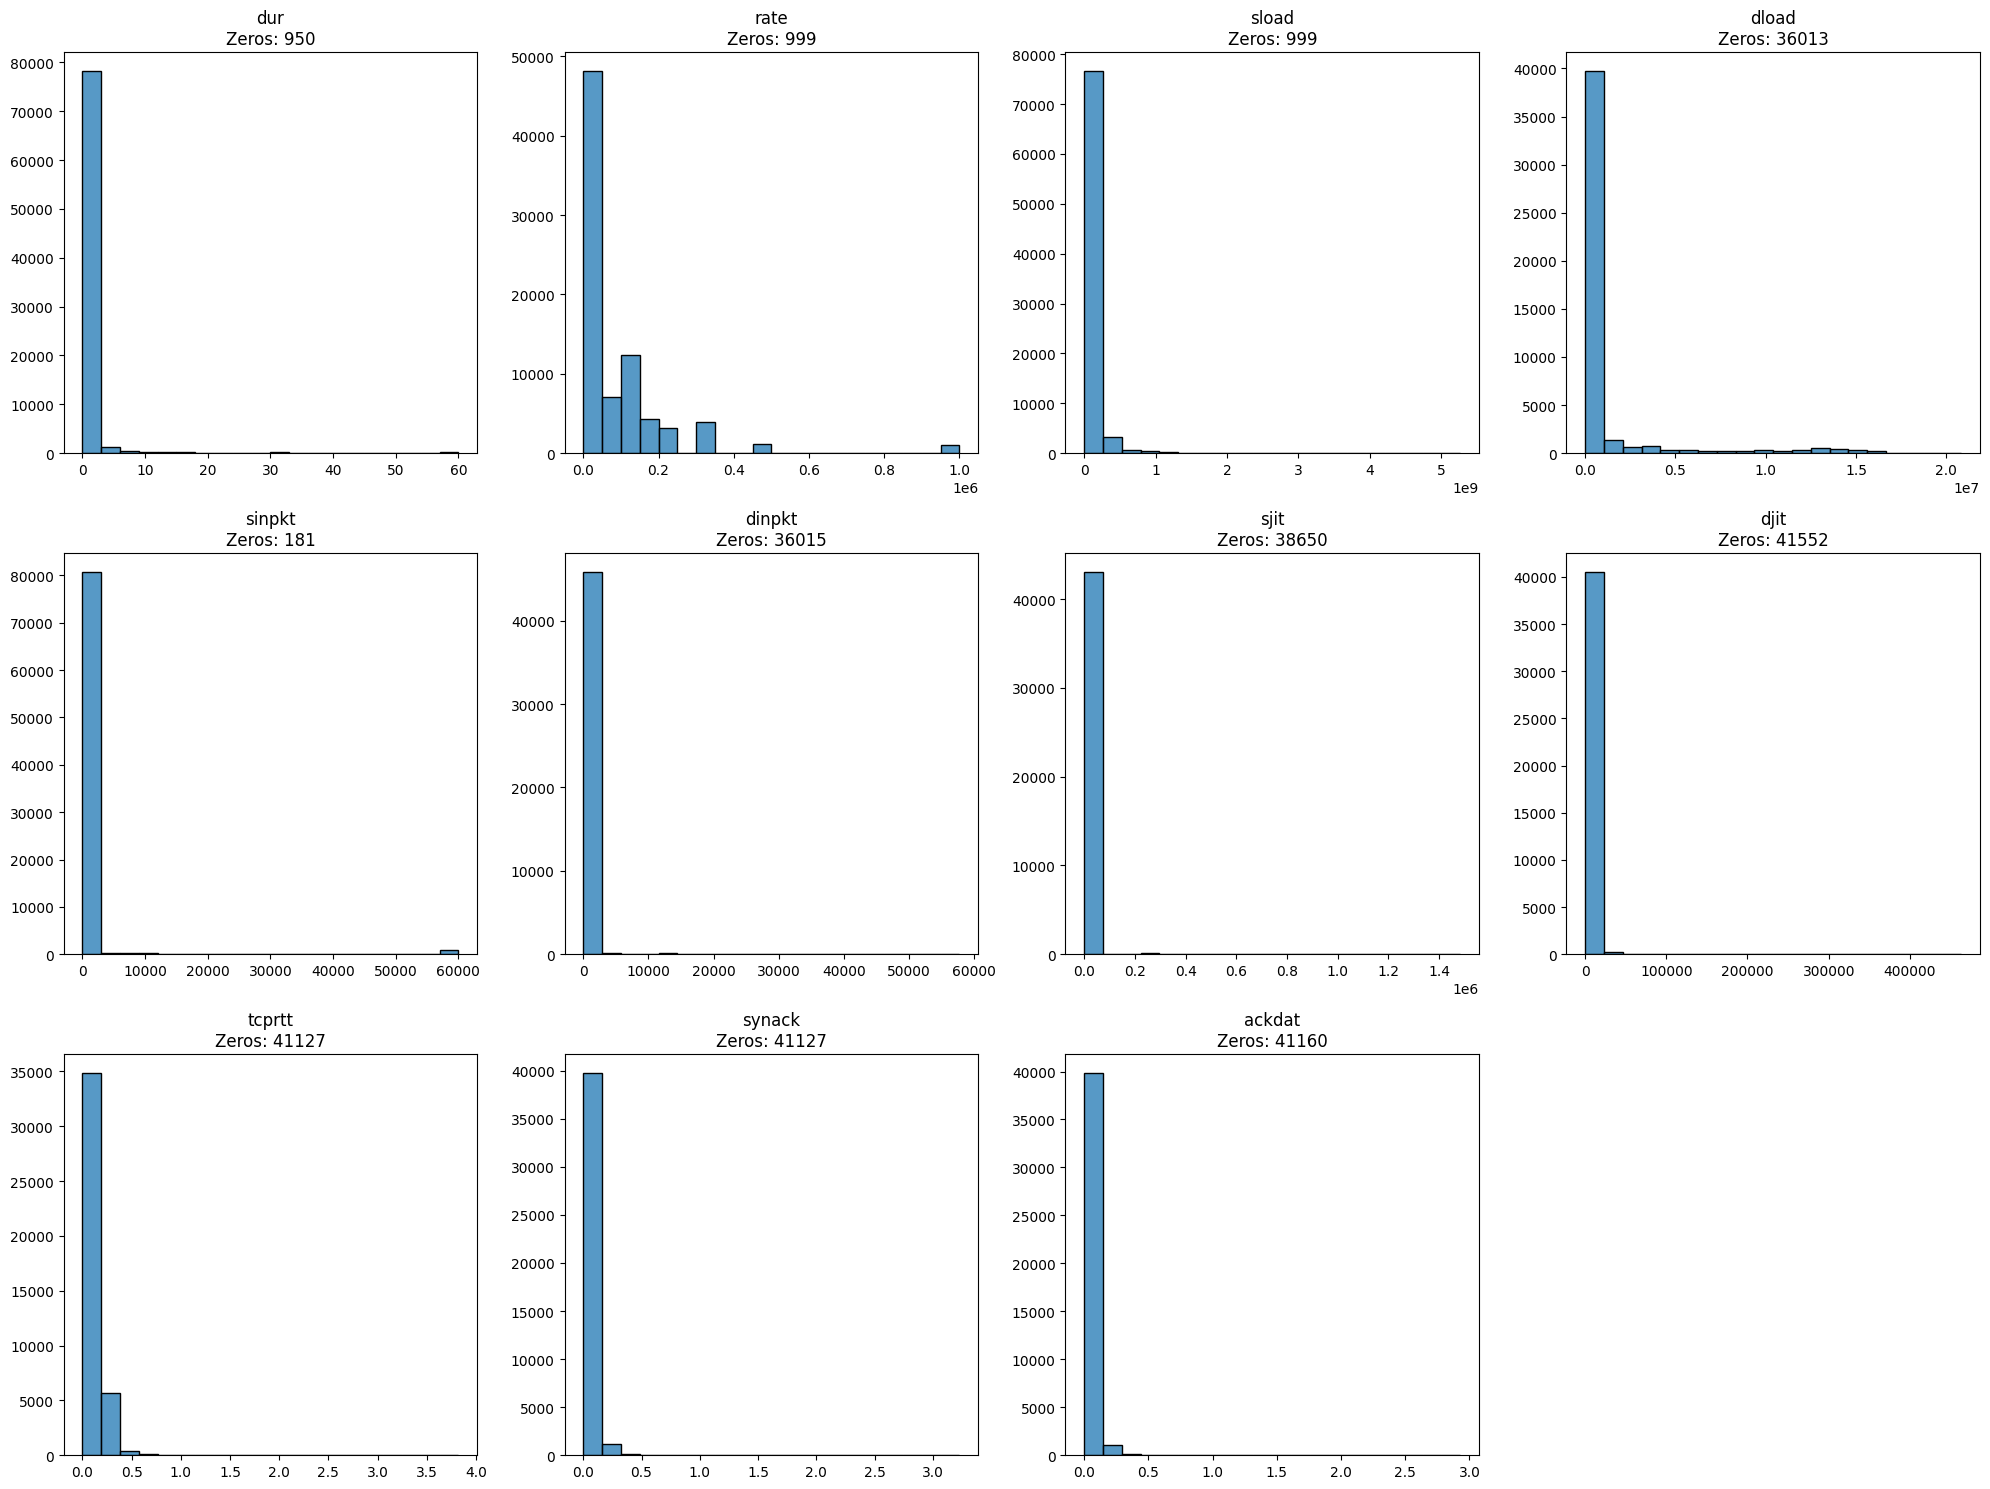

In [85]:
n_cols = 4
n_rows = math.ceil(len(num_features_float) / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(num_features_float, 1):
    plt.subplot(n_rows, n_cols, i)

    # Comptage des zéros
    zero_count = (df_features[col] == 0).sum()

    # Données sans les zéros
    data_no_zero = df_features.loc[df_features[col] != 0, col]

    # Histogramme sans les zéros
    sns.histplot(data_no_zero, bins=20)

    plt.title(f"{col}\nZeros: {zero_count}")
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

In [86]:
stats_df = pd.DataFrame()

for col in num_features:
    data = df_features[col].dropna()

    mean = data.mean()
    std = data.std()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    stats_df.loc[col, "count"] = data.count()
    stats_df.loc[col, "mean"] = mean
    stats_df.loc[col, "std"] = std
    stats_df.loc[col, "min"] = data.min()
    stats_df.loc[col, "25%"] = q1
    stats_df.loc[col, "50%"] = data.median()
    stats_df.loc[col, "75%"] = q3
    stats_df.loc[col, "max"] = data.max()

    stats_df.loc[col, "coef_variation"] = std / mean if mean != 0 else np.nan
    stats_df.loc[col, "skewness"] = skew(data)
    stats_df.loc[col, "kurtosis"] = kurtosis(data)
    stats_df.loc[col, "IQR"] = iqr
    stats_df.loc[col, "IQR_std_ratio"] = iqr / std if std != 0 else np.nan

stats_df.sort_values("coef_variation", ascending=False).round(4).head(10)

,count,mean,std,min,25%,50%,75%,max,coef_variation,skewness,kurtosis,IQR,IQR_std_ratio
response_body_len,82332.0,1595.3719,38066.9723,0.0,0.0,0.0000,0.0000,5.242880e+06,23.8609,74.6338,9070.5558,0.0000,0.0000
sbytes,82332.0,7993.9082,171642.2619,24.0,114.0,534.0000,1280.0000,1.435577e+07,21.4716,53.7776,3304.6578,1166.0000,0.0068
sloss,82332.0,4.7537,64.6496,0.0,0.0,1.0000,3.0000,5.319000e+03,13.5999,52.4643,3181.3103,3.0000,0.0464
dbytes,82332.0,13233.7856,151471.4561,0.0,0.0,178.0000,956.0000,1.465753e+07,11.4458,52.5494,4175.2490,956.0000,0.0063
ct_ftp_cmd,82332.0,0.0084,0.0925,0.0,0.0,0.0000,0.0000,2.000000e+00,11.0355,11.2430,130.6704,0.0000,0.0000
is_ftp_login,82332.0,0.0083,0.0912,0.0,0.0,0.0000,0.0000,2.000000e+00,11.0063,11.0421,122.6755,0.0000,0.0000
dinpkt,82332.0,121.7013,1292.3785,0.0,0.0,0.0100,63.1364,5.773924e+04,10.6193,23.0126,669.6416,63.1364,0.0489
is_sm_ips_ports,82332.0,0.0111,0.1049,0.0,0.0,0.0000,0.0000,1.000000e+00,9.4278,9.3217,84.8933,0.0000,0.0000
sjit,82332.0,6363.0751,56724.0167,0.0,0.0,17.6239,3219.3324,1.483831e+06,8.9146,15.3491,254.0720,3219.3324,0.0568
dloss,82332.0,6.3086,55.7080,0.0,0.0,0.0000,2.0000,5.507000e+03,8.8306,54.4647,4435.5639,2.0000,0.0359


Globalement, les varialbes offrent peu de variation.